In [1]:
import glob
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

Tested on Nebius.AI:
   - GPU: 1xH100 80GB SXM (NVIDIA® H100 NVLink with Intel Sapphire Rapids)
   - Host System: Ubuntu 22.04 LTS for NVIDIA® GPUs (CUDA® 12)

### H100 NF4 Inference Benchmark

In [2]:
data_path = "H100_10_iter_3_runs/benchmark_results/"

In [3]:
raw_data = []
runs = os.listdir(data_path)
for run in runs:
    if not os.path.isdir(os.path.join(data_path,run)): continue
    branches = os.listdir(os.path.join(data_path, run))
    for branch in branches:
        path_to_models = os.path.join(data_path, run, branch)
        if not os.path.isdir(path_to_models): continue
        models = os.listdir(path_to_models)
        for model in models:
            data_files = glob.glob(os.path.join(data_path, run, branch, model, "*.json"))
            for filepath in data_files:
                # benchmark-nf4-bsz-1-isz-512-osz-64-iter10-wrmup-1-blksz64
                experiment = os.path.basename(filepath)[:-5].split("-")
                raw_data.append({
                    "run": run,
                    "branch": branch,
                    "file": filepath,
                    "model": model,
                    "config": experiment[1],
                    "batch_size": experiment[3],
                    "input_size": experiment[5],
                    "output_size": experiment[7],
                    "iterations": experiment[9],
                    "warmup": experiment[11],
                    "blocksize": experiment[13] if 13<len(experiment) else -1,
                })

metadata_df = pd.DataFrame(raw_data)
metadata_df

,run,branch,file,model,config,batch_size,input_size,output_size,iterations,warmup,blocksize
0,run_1,cuda-branchless-dequantization-float32-lut,H100_10_iter_3_runs/benchmark_results/run_1\cu...,Llama-3.1-70B,nf4,1,2048,128,10,10,64
1,run_1,cuda-branchless-dequantization-float32-lut,H100_10_iter_3_runs/benchmark_results/run_1\cu...,Llama-3.1-70B,nf4,16,2048,128,10,10,64
2,run_1,cuda-branchless-dequantization-float32-lut,H100_10_iter_3_runs/benchmark_results/run_1\cu...,Llama-3.1-70B,nf4,4,2048,128,10,10,64
3,run_1,cuda-branchless-dequantization-float32-lut,H100_10_iter_3_runs/benchmark_results/run_1\cu...,Llama-3.1-70B,nf4,8,2048,128,10,10,64
4,run_1,main,H100_10_iter_3_runs/benchmark_results/run_1\ma...,Llama-3.1-70B,nf4,1,2048,128,10,10,64
5,run_1,main,H100_10_iter_3_runs/benchmark_results/run_1\ma...,Llama-3.1-70B,nf4,16,2048,128,10,10,64
6,run_1,main,H100_10_iter_3_runs/benchmark_results/run_1\ma...,Llama-3.1-70B,nf4,4,2048,128,10,10,64
7,run_1,main,H100_10_iter_3_runs/benchmark_results/run_1\ma...,Llama-3.1-70B,nf4,8,2048,128,10,10,64
8,run_2,cuda-branchless-dequantization-float32-lut,H100_10_iter_3_runs/benchmark_results/run_2\cu...,Llama-3.1-70B,nf4,1,2048,128,10,10,64
9,run_2,cuda-branchless-dequantization-float32-lut,H100_10_iter_3_runs/benchmark_results/run_2\cu...,Llama-3.1-70B,nf4,4,2048,128,10,10,64


In [4]:
dfs = []
for _, row in metadata_df.iterrows():
    dff = pd.read_json(row["file"]).T
    dff["model"] = row["model"]
    dff["branch"] = row["branch"]
    dff["config"] = row["config"]
    dff["batch_size"] = int(row["batch_size"])
    dff["run"] = row["run"]
    dff["input_size"] = row["input_size"]
    dff["output_size"] = row["output_size"]
    dfs.append(dff)
df = pd.concat(dfs)

def expand_dict_column(df, col):
    expanded = df[col].apply(pd.Series)
    if expanded is not None:
        keys = keys_to_expand.get(col, None)
        if keys:
            expanded = expanded[keys]
        expanded = expanded.add_prefix(f"{col}_")
        return expanded
    return None

# apply the function to all columns that contain dicts
expanded_parts = []
keys_to_expand = {"latency": ["total", "mean", "p50", "stdev_"],}
exclude = ["memory", "energy", "efficiency"]
for col in df.drop(columns=exclude).columns:
    if df[col].apply(lambda x: isinstance(x, dict)).any():
        expanded = expand_dict_column(df, col)
        expanded_parts.append(expanded)

other_branch = "cuda-branchless-dequantization-float32-lut"
baseline_branch = "main"

# merge all expansions with the original df
df_final = pd.concat([df.drop(columns=exclude), *expanded_parts], axis=1)
mask = df_final.branch.isin([other_branch, baseline_branch])

In [5]:
# get a dataframe for statistical analysis
df_final["latency_values"] = df_final.latency.apply(lambda d: d.get('values'))
index_mask = df_final.index.isin(["prefill", "decode"])
stability_df = df_final[mask].loc[index_mask].reset_index()
stability_df = stability_df[stability_df["batch_size"]!=16] # batch 16 only had 1 run
stability_df = stability_df.groupby(["model", "input_size", "output_size", 'config', 'branch', "batch_size", "index", "run"])[["latency_values"]].first()
stability_df = stability_df.sort_index(level=4)
stability_df.head()

latency_values
model         input_size output_size config branch                                     batch_size index   run                                                     
Llama-3.1-70B 2048       128         nf4    cuda-branchless-dequantization-float32-lut 1          decode  run_1  [14.030415496826173, 14.050003387451172, 14.04...
                                                                                                          run_2  [14.208649194335937, 14.157849389648439, 14.20...
                                                                                                          run_3  [14.267172497558594, 14.320395153808594, 14.33...
                                                                                                  prefill run_1  [0.673307983398437, 0.67825830078125, 0.674339...
                                                                                                          run_2  [0.674724304199218, 0.676406494140625, 0.67591...

In [6]:
cols = ["latency_total", "latency_mean", "latency_p50", "throughput_value"]
data = df_final[mask].reset_index().groupby(["model", "input_size", "output_size", 'config', "batch_size", "index", "run", 'branch'])[cols].first()
baseline = data.xs(baseline_branch, level=7)
improved = data.xs(other_branch, level=7)

# less is better for latency
diff = (baseline-improved)/baseline * 100

# higher is better for throughput
diff["throughput_value"] *= -1

index_mask = diff.index.get_level_values(5).isin(["prefill", "decode"])

diff = diff.add_suffix("_diff_%")

# aggregate over all runs (mean)
run_agg_diff = diff[index_mask].reset_index().groupby(["model", "input_size", "output_size", 'config', "index", "batch_size"])[diff.columns].mean().sort_index(level=4)
run_agg_diff.round(3)

latency_total_diff_%  \
model         input_size output_size config index   batch_size                         
Llama-3.1-70B 2048       128         nf4    decode  1                         -0.079   
                                                    4                         26.080   
                                                    8                         24.983   
                                                    16                        23.849   
                                            prefill 1                         10.868   
                                                    4                          3.757   
                                                    8                          1.852   
                                                    16                         0.987   

                                                                latency_mean_diff_%  \
model         input_size output_size config index   batch_size                        
Llama-3.1-70B 2048       128         nf4    decode  1                        -0.079   
                                                    4                        26.080   
                                                    8                        24.983   
                                                    16                       23.849   
                                            prefill 1                        10.868   
                                                    4                         3.757   
                                                    8                         1.852   
                                                    16                        0.987   

                                                                latency_p50_diff_%  \
model         input_size output_size config index   batch_size                       
Llama-3.1-70B 2048       128         nf4    decode  1                       -0.054   
                                                    4                       26.096   
                                                    8                       25.010   
                                                    16                      23.794   
                                            prefill 1                       10.829   
                                                    4                        3.746   
                                                    8                        1.823   
                                                    16                       0.984   

                                                                throughput_value_diff_%  
model         input_size output_size config index   batch_size                           
Llama-3.1-70B 2048       128         nf4    decode  1                            -0.076  
                                                    4                            35.284  
                                                    8                            33.306  
                                                    16                           31.318  
                                            prefill 1                            12.194  
                                                    4                             3.904  
                                                    8                             1.886  
                                                    16                            0.997

#### Stability Checking

##### Stability Across Runs (Levene's Test)

In [7]:
stability_df.head()

latency_values
model         input_size output_size config branch                                     batch_size index   run                                                     
Llama-3.1-70B 2048       128         nf4    cuda-branchless-dequantization-float32-lut 1          decode  run_1  [14.030415496826173, 14.050003387451172, 14.04...
                                                                                                          run_2  [14.208649194335937, 14.157849389648439, 14.20...
                                                                                                          run_3  [14.267172497558594, 14.320395153808594, 14.33...
                                                                                                  prefill run_1  [0.673307983398437, 0.67825830078125, 0.674339...
                                                                                                          run_2  [0.674724304199218, 0.676406494140625, 0.67591...

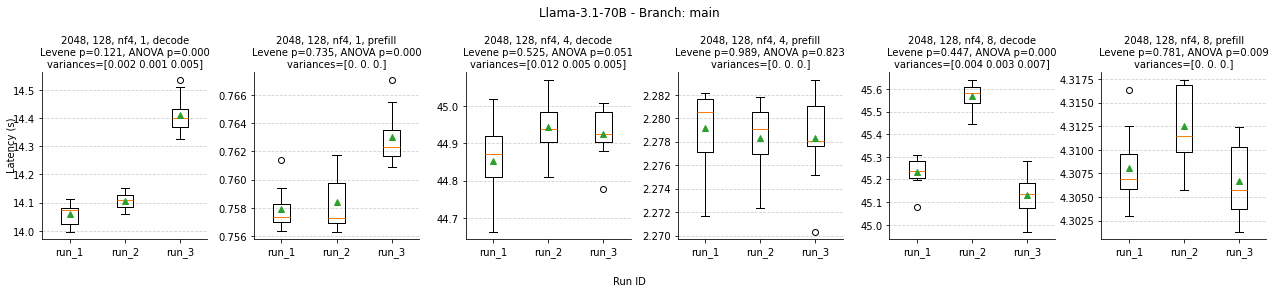

Test ('Llama-3.1-70B', '2048', '128', 'nf4', 8, 'decode') is rejected. Variances: [0.007 0.037 0.01 ]


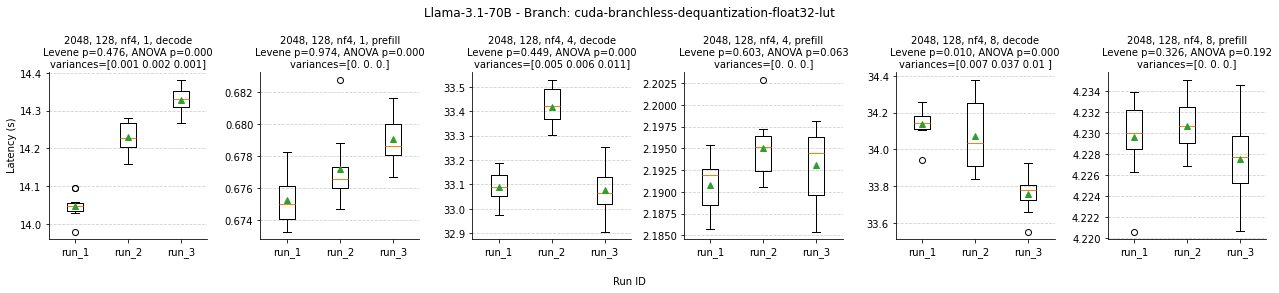

In [8]:
# get all run ids
run_ids = diff.index.get_level_values(6).unique()
branches = [baseline_branch, other_branch]
for branch in branches:
    branch_df = stability_df.xs(branch, level=4)

    nrows = 1
    ncols = branch_df.shape[0]//len(run_ids)
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3, nrows * 4))

    # each unique configuration of (model, input_size, output_size, config, batch_size, index) will have N runs
    # do levene test on these runs
    for i in range(branch_df.shape[0]//len(run_ids)):
        # the current index points to a configuraton of (model	input_size	output_size	config	batch_size	index)
        runs = [branch_df.xs(run_id, level=6).iloc[i]["latency_values"] for run_id in run_ids]
        sample_variances = np.round([np.var(r, ddof=1) for r in runs], 3)
        index = branch_df.xs(run_ids[0], level=6).iloc[i].to_frame().T.index.tolist()[0]
        _, p_value = stats.levene(*runs)
        _, anova_p_value = stats.f_oneway(*runs)
        rejection_status = "reject" if p_value < 0.05 else "no significant difference"
        # print(f"\t {str(index):55}: {rejection_status:30}, {p_value:0.7f}")
        if rejection_status == "reject":
            print("Test", index, "is rejected. Variances:", sample_variances)

        model_name, *index = index
        index = ', '.join(map(str, index))
        ax = axes[i]
        ax.boxplot(runs, labels=run_ids, showmeans=True)
        ax.set_title(
            f"{index}\n"
            f"Levene p={p_value:.3f}, ANOVA p={anova_p_value:.3f}\n"
            f"variances={sample_variances}", fontsize=10)
        ax.grid(axis="y", linestyle="--", alpha=0.6)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    fig.suptitle(f"{model_name} - Branch: {branch}")
    fig.supxlabel("Run ID", fontsize=10)
    fig.supylabel("Latency (s)", fontsize=10)
    plt.tight_layout()
    plt.show()

Observations and notes:
- Levene's test assess the equality of variances between two or more groups of a measured variable
- ANOVA determines if there are significant differences between the means of three or more independent groups. ANOVA is too senstive for this benchmark. 
- Since the variances between runs are almost identical (levene's p >= 0.05) and variance is low, the benchmark is stable enough.
- Be careful of the range of the y axis of each plot because it might trick you.

##### Baseline vs Improved (Paired t-tests per Run)

In [9]:
# run a PAIRED t-test between different branches
column = "latency_values"

baseline_s_df = stability_df.xs(baseline_branch, level=4)
improved_s_df = stability_df.xs(other_branch, level=4)

for run_id in run_ids:
    print(run_id)
    baseline_run = baseline_s_df.xs(run_id, level=6)
    improved_run = improved_s_df.xs(run_id, level=6)
    assert (improved_run.index == baseline_run.index).all()
    for config_idx in range(improved_s_df.shape[0]//len(run_ids)):
        baseline_config_data = baseline_run.iloc[config_idx]["latency_values"]
        improved_config_data = improved_run.iloc[config_idx]["latency_values"]
        index = baseline_s_df.xs(run_ids[0], level=6).iloc[config_idx].to_frame().T.index.tolist()[0]
        index = ', '.join(map(str,index))

        # the improved should always be better
        # so set alternative hypotthesis to be less
        t_stat, p_value = stats.ttest_rel(baseline_config_data, improved_config_data, alternative='less')

        rejection_status = " ~ no significant difference ~ " if p_value < 0.05 else "significant difference!"
        # print(index, rejection_status, stats)
        m1 = np.mean(baseline_config_data)
        m2 = np.mean(improved_config_data)
        print(
            f"\t {index:41}: baseline={m1:06.03f}, "
            f"improved={m2:06.03f}, "
            f"percentage_diff={(m1-m2)/m1*100:05.02f}%, "
            f"result= {rejection_status:25}"
        )

    print()

run_1
	 Llama-3.1-70B, 2048, 128, nf4, 1, decode : baseline=14.058, improved=14.047, percentage_diff=00.08%, result= significant difference!  
	 Llama-3.1-70B, 2048, 128, nf4, 1, prefill: baseline=00.758, improved=00.675, percentage_diff=10.90%, result= significant difference!  
	 Llama-3.1-70B, 2048, 128, nf4, 4, decode : baseline=44.852, improved=33.089, percentage_diff=26.23%, result= significant difference!  
	 Llama-3.1-70B, 2048, 128, nf4, 4, prefill: baseline=02.279, improved=02.191, percentage_diff=03.88%, result= significant difference!  
	 Llama-3.1-70B, 2048, 128, nf4, 8, decode : baseline=45.232, improved=34.139, percentage_diff=24.53%, result= significant difference!  
	 Llama-3.1-70B, 2048, 128, nf4, 8, prefill: baseline=04.308, improved=04.230, percentage_diff=01.82%, result= significant difference!  

run_2
	 Llama-3.1-70B, 2048, 128, nf4, 1, decode : baseline=14.106, improved=14.231, percentage_diff=-0.88%, result=  ~ no significant difference ~ 
	 Llama-3.1-70B, 2048,

Observation: There is a statistically significant improvement. 

In [10]:
# uncomment to check actual values, not percent differences
run_agg_baseline = baseline[index_mask].reset_index().groupby(["model", "input_size", "output_size", 'config', "index", "batch_size"])[baseline.columns].mean().sort_index(level=4)
run_agg_baseline

latency_total  \
model         input_size output_size config index   batch_size                  
Llama-3.1-70B 2048       128         nf4    decode  1              141.916140   
                                                    4              449.072115   
                                                    8              453.105541   
                                                    16             465.208310   
                                            prefill 1                7.597631   
                                                    4               22.785880   
                                                    8               43.090889   
                                                    16              84.036351   

                                                                latency_mean  \
model         input_size output_size config index   batch_size                 
Llama-3.1-70B 2048       128         nf4    decode  1              14.191614   
                                                    4              44.907211   
                                                    8              45.310554   
                                                    16             46.520831   
                                            prefill 1               0.759763   
                                                    4               2.278588   
                                                    8               4.309089   
                                                    16              8.403635   

                                                                latency_p50  \
model         input_size output_size config index   batch_size                
Llama-3.1-70B 2048       128         nf4    decode  1             14.194529   
                                                    4             44.911473   
                                                    8             45.318457   
                                                    16            46.501759   
                                            prefill 1              0.758975   
                                                    4              2.279239   
                                                    8              4.308036   
                                                    16             8.402650   

                                                                throughput_value  
model         input_size output_size config index   batch_size                    
Llama-3.1-70B 2048       128         nf4    decode  1                   8.950019  
                                                    4                  11.312223  
                                                    8                  22.423415  
                                                    16                 43.679357  
                                            prefill 1                   1.316212  
                                                    4                   1.755473  
                                                    8                   1.856542  
                                                    16                  1.903938

In [11]:
# uncomment to check actual values, not percent differences
run_agg_improved = improved[index_mask].reset_index().groupby(["model", "input_size", "output_size", 'config', "index", "batch_size"])[improved.columns].mean().sort_index(level=4)
run_agg_improved

latency_total  \
model         input_size output_size config index   batch_size                  
Llama-3.1-70B 2048       128         nf4    decode  1              142.022442   
                                                    4              331.953583   
                                                    8              339.902626   
                                                    16             354.260538   
                                            prefill 1                6.771872   
                                                    4               21.929750   
                                                    8               42.293035   
                                                    16              83.206524   

                                                                latency_mean  \
model         input_size output_size config index   batch_size                 
Llama-3.1-70B 2048       128         nf4    decode  1              14.202244   
                                                    4              33.195358   
                                                    8              33.990263   
                                                    16             35.426054   
                                            prefill 1               0.677187   
                                                    4               2.192975   
                                                    8               4.229303   
                                                    16              8.320652   

                                                                latency_p50  \
model         input_size output_size config index   batch_size                
Llama-3.1-70B 2048       128         nf4    decode  1             14.201683   
                                                    4             33.191524   
                                                    8             33.983860   
                                                    16            35.437096   
                                            prefill 1              0.676781   
                                                    4              2.193856   
                                                    8              4.229486   
                                                    16             8.319987   

                                                                throughput_value  
model         input_size output_size config index   batch_size                    
Llama-3.1-70B 2048       128         nf4    decode  1                   8.942854  
                                                    4                  15.303693  
                                                    8                  29.891632  
                                                    16                 57.358915  
                                            prefill 1                   1.476704  
                                                    4                   1.824007  
                                                    8                   1.891565  
                                                    16                  1.922926

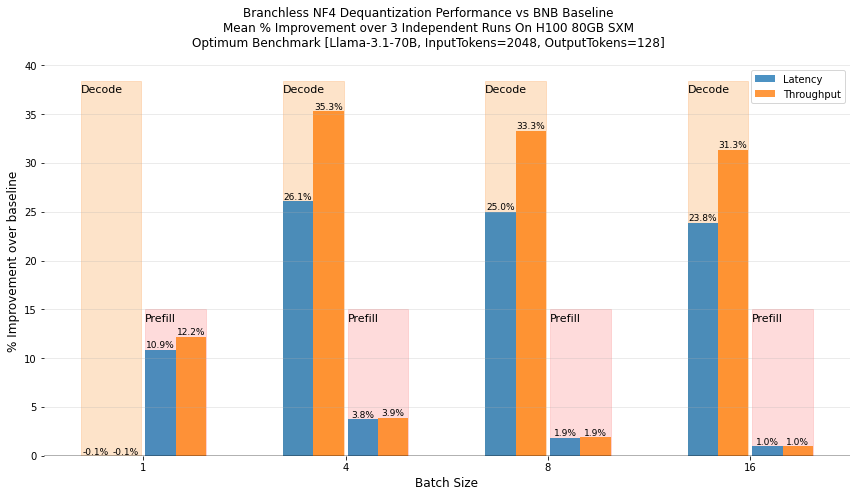

In [12]:
def plot_summary_histogram(plot_df, n_runs):
    groups = plot_df.groupby("index")
    group_list = list(groups)

    batch_sizes = plot_df['batch_size'].unique()
    fig, ax = plt.subplots(figsize=(12, 7))

    bar_width = 0.15
    group_spacing = 0.02
    y_axis_range = (0, 40)
    y_axis_length = abs(y_axis_range[1] - y_axis_range[0])

    # latency, throughput
    colors = ["#1f77b4", "#ff7f0e"]
    
    # prefill, decode
    shading = ["#FDB0B0", "#FCC189"]
    x_pos = np.arange(len(batch_sizes))

    for group_idx, (key, group) in enumerate(group_list):
        group_offset = (group_idx - (len(group_list)-1)/2) * (bar_width * 2 + group_spacing)
        
        latency_vals, throughput_vals = [], []
        
        for batch_size in batch_sizes:
            batch_data = group[group['batch_size'] == batch_size]
            latency_vals.append(batch_data['latency_mean_diff_%'].iloc[0])
            throughput_vals.append(batch_data['throughput_value_diff_%'].iloc[0])

        lat_pos = x_pos + group_offset - bar_width/2
        thr_pos = x_pos + group_offset + bar_width/2
        
        bars_lat = list(ax.bar(lat_pos, latency_vals, bar_width, color=colors[0],
                        label='Latency' if group_idx == 0 else "", alpha=0.8))
        bars_thr = list(ax.bar(thr_pos, throughput_vals, bar_width, color=colors[1],
                        label='Throughput' if group_idx == 0 else "", alpha=0.8))

        for bar in bars_lat+ bars_thr:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2, height,
                    f"{height:.1f}%", ha='center', va='bottom', fontsize=9, color='black')

        for i, x in enumerate(lat_pos):
            xmin = x - bars_thr[i].get_width() * 0.5
            xmax = x + bars_thr[i].get_width() * 1.5
            height = (.96, 37) if key == 'decode' else (0.375, 13.5)
            color = shading[key == 'decode']
            ax.axvspan(xmin, xmax, 0/y_axis_length, height[0], alpha=0.45, zorder=0, color=color)
            ax.text(xmin, height[1], key.capitalize(), ha='left', va='bottom', fontsize=11)

    ax.set_ylim(*y_axis_range)
    ax.set_ylabel('% Improvement over baseline', fontsize=12)

    entry = plot_df.iloc[0]
    model_name = entry["model"]
    input_size = entry["input_size"]
    output_size = entry["output_size"]
    output_size = entry["output_size"]

    # share x-axis
    ax.set_xticks(x_pos)
    ax.set_xticklabels([f'{bs}' for bs in batch_sizes])
    ax.set_xlabel('Batch Size', fontsize=12)
    ax.legend(loc='upper right')
    ax.grid(True, axis='y', alpha=0.3)
    ax.axhline(y=0, color='black', linestyle='-', alpha=0.4)

    for spine in list(ax.spines.values()):
        spine.set_visible(False)
    plt.suptitle(
        f"Branchless NF4 Dequantization Performance vs BNB Baseline\n"
        f"Mean % Improvement over {n_runs} Independent Runs On H100 80GB SXM\n"
        f"Optimum Benchmark [{model_name}, InputTokens={input_size}, OutputTokens={output_size}]"
        ,fontsize=12
    )
    ax.set_facecolor("white")
    fig.patch.set_facecolor("white")
    plt.tight_layout()
    plt.show()
    return fig

run_ids = diff.reset_index()["run"].unique()
plot_df = run_agg_diff.reset_index()
fig = plot_summary_histogram(plot_df, len(run_ids))
fig.savefig("H100_Inference_Benchmark.png", dpi=300, bbox_inches='tight', facecolor='white')


Observations:
 - For decode, for batch sizes greater than 1, throughput is improved by ~33% and latency is reduced by ~25%.
 - For prefill, throughput is improved by ~12% and latency is reduced by ~10% when the batch size is 1. The effect diminishes with larger batch sizes so further investigation may be needed here.

### H100 NF4 Custom Stress Test

#### Stress Test Results

In [13]:
MEASURE = "total"
METRICS = [f"quantize_dequantize_latency_{MEASURE}", f"quantize_latency_{MEASURE}", f"dequantize_latency_{MEASURE}"]

In [14]:
runs = os.listdir(data_path)
dfs = []
for run_id in runs:
    if not os.path.isdir(os.path.join(data_path,run_id)): continue
    branches = os.path.join(data_path, run_id)
    for branch in os.listdir(branches):
        branch_data_path = os.path.join(data_path, run_id, branch, "stress_test_run.csv")
        if not os.path.exists(branch_data_path): continue
        branch_df = pd.read_csv(branch_data_path)
        branch_df["branch"] = branch
        branch_df["run"] = run_id
        dfs.append(branch_df)

# any column would do the trick
lookup = "quantize_dequantize_latency_"
N_STRESS_TEST_ITERATIONS = branch_df.iloc[0][lookup+"count"]
print("Iterations:", N_STRESS_TEST_ITERATIONS)

data_df = pd.concat(dfs)
data_df = data_df.groupby(["run", "dtype", "quant_type", "branch",  "blocksize", "tensor_shape"])[METRICS].first().sort_index()
DTYPE = "torch.float32"
QUANT_TYPE = "nf4"
RUN_ID = "run_1"
data_df = data_df.xs(RUN_ID, level=0)
data_df = data_df.xs(DTYPE, level=0)
data_df = data_df.xs(QUANT_TYPE, level=0)
data_df

Iterations: 1000


quantize_dequantize_latency_total  \
branch                                     blocksize tensor_shape                                      
cuda-branchless-dequantization-float32-lut 64        1024                                  80.332000   
                                                     2048                                 111.739008   
                                                     4096                                 243.636640   
                                                     8192                                 802.231008   
                                                     16384                               3011.953213   
...                                                                                              ...   
main                                       4096      1024                                  78.357408   
                                                     2048                                 108.996768   
                                                     4096                                 330.286978   
                                                     8192                                 854.601216   
                                                     16384                               3234.467105   

                                                                   quantize_latency_total  \
branch                                     blocksize tensor_shape                           
cuda-branchless-dequantization-float32-lut 64        1024                       53.507072   
                                                     2048                       82.832640   
                                                     4096                      203.997856   
                                                     8192                      677.098720   
                                                     16384                    2579.207557   
...                                                                                   ...   
main                                       4096      1024                       52.865824   
                                                     2048                       82.163168   
                                                     4096                      200.742240   
                                                     8192                      675.571935   
                                                     16384                    2573.057825   

                                                                   dequantize_latency_total  
branch                                     blocksize tensor_shape                            
cuda-branchless-dequantization-float32-lut 64        1024                          6.182400  
                                                     2048                          9.992416  
                                                     4096                         32.548448  
                                                     8192                        111.884704  
                                                     16384                       427.860256  
...                                                                                     ...  
main                                       4096      1024                          8.411680  
                                                     2048                         15.545184  
                                                     4096                         46.937568  
                                                     8192                        168.419008  
                                                     16384                       649.707073  

[70 rows x 3 columns]

In [15]:
data_df.reset_index()["branch"].unique().tolist()

['cuda-branchless-dequantization-float32-lut', 'main']

In [16]:
stress_test_baseline = data_df.xs(baseline_branch, level=0)
stress_test_improved = data_df.xs(other_branch, level=0)
assert (stress_test_baseline.index.equals(stress_test_improved.index))
stress_diff = (stress_test_baseline-stress_test_improved)/stress_test_baseline * 100
stress_diff = stress_diff.add_suffix("_%")
stress_diff

quantize_dequantize_latency_total_%  \
blocksize tensor_shape                                        
64        1024                                    -1.915233   
          2048                                    -1.177853   
          4096                                     5.974167   
          8192                                     6.108432   
          16384                                    6.942150   
128       1024                                     1.362114   
          2048                                    -1.075436   
          4096                                     6.012117   
          8192                                     6.804109   
          16384                                    6.814549   
256       1024                                    -4.007967   
          2048                                    -1.370563   
          4096                                     5.997094   
          8192                                     6.769804   
          16384                                    6.644400   
512       1024                                    -2.490189   
          2048                                    -1.536264   
          4096                                     5.534742   
          8192                                     6.720682   
          16384                                    6.703019   
1024      1024                                    -1.594845   
          2048                                    -1.554358   
          4096                                     6.252020   
          8192                                     6.757044   
          16384                                    7.008233   
2048      1024                                    -0.508624   
          2048                                     3.212883   
          4096                                     5.982813   
          8192                                     6.734976   
          16384                                    6.820938   
4096      1024                                    -3.414508   
          2048                                    -1.553250   
          4096                                     3.383609   
          8192                                     6.522149   
          16384                                    6.843993   

                        quantize_latency_total_%  dequantize_latency_total_%  
blocksize tensor_shape                                                        
64        1024                          3.866672                   26.465830  
          2048                         -0.310520                   35.740950  
          4096                         -1.101920                   30.712650  
          8192                         -0.140395                   33.575412  
          16384                        -0.216007                   34.154093  
128       1024                          0.896407                   26.861494  
          2048                         -1.618115                   35.788863  
          4096                         -0.262619                   30.695319  
          8192                         -0.157554                   33.842529  
          16384                        -0.125900                   34.179305  
256       1024                         -2.652707                   26.304866  
          2048                         -0.436456                   35.866773  
          4096                          0.487981                   30.726165  
          8192                          0.097428                   33.782541  
          16384                         0.006854                   34.155061  
512       1024                          1.924264                   26.558728  
          2048                          0.021591                   35.721048  
          4096                         -0.502342                   30.636718  
          8192                         -0.341636                   33.737125  
          16384                  

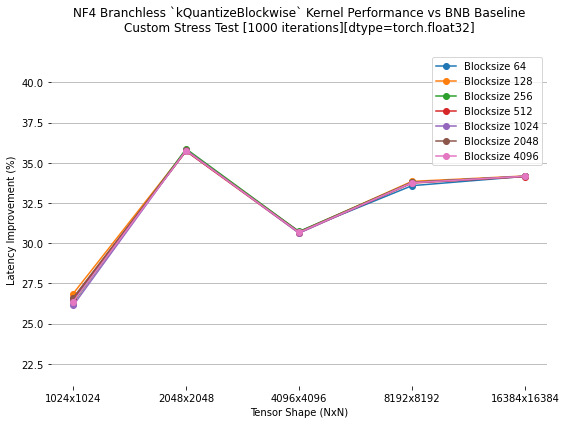

In [17]:
def plot(diff, column, kernel_name):
    d = diff.reset_index()
    d["dim"] = d["tensor_shape"]
    d["tensor_shape"] = d["dim"] ** 2

    # start plot
    fig, ax = plt.subplots(figsize=(8, 6))
    max_v, min_v = -100, 100
    for blocksize, subdf in d.groupby("blocksize"):
        ax.plot(
            list(range(subdf[column].shape[0])),
            subdf[column].values,
            marker="o",
            label=f"Blocksize {blocksize}"
        )
        min_v = min(min_v, subdf[column].min())
        max_v = max(max_v, subdf[column].max())

    # custom ticks
    # tickvals = d["tensor_shape"].unique()
    ticktext = [f"{dim}x{dim}" for dim in d["dim"].unique()]
    # ax.set_xscale("log")
    ax.set_xticks(range(subdf[column].shape[0]))
    ax.set_xticklabels(ticktext)#, rotation=45, ha="right")
    # print(ticktext)

    # labels and title
    ax.set_xlabel("Tensor Shape (NxN)")
    ax.set_ylabel("Latency Improvement (%)")
    ax.set_title(
        f"NF4 Branchless `{kernel_name}` Kernel Performance vs BNB Baseline\n"
        f"Custom Stress Test [{N_STRESS_TEST_ITERATIONS} iterations][dtype={DTYPE}]\n"
    )
    for spine in list(ax.spines.values()):
        spine.set_visible(False)
    ax.axhline(y=0, color='black', linestyle='-', alpha=0.4)
    ax.grid(True, axis='x', alpha=0.2)
    ax.set_ylim(min_v-5, max_v+6)
    plt.tight_layout()
    plt.grid()
    plt.legend(loc="upper right")
    plt.show()

# plot(diff, f"quantize_latency_{MEASURE}_%", "")
# plot(diff, f"quantize_dequantize_latency_{MEASURE}_%", "")
plot(stress_diff, f"dequantize_latency_{MEASURE}_%", "kQuantizeBlockwise")

#### NCU Results

In [18]:
METRICS_TO_KEEP = [
    "gpu__time_duration_measured_user.avg",
    "smsp__sass_branch_targets_threads_divergent.sum",
    "sm__throughput.avg.pct_of_peak_sustained_elapsed",
    "dram__throughput.avg.pct_of_peak_sustained_elapsed",
]

In [19]:
def load_ncu_metadata(path, csv_name="stress_test_ncu_metadata.csv"):
    branches = os.listdir(path)
    dfs = []
    for branch in branches:
        branch_data_path = os.path.join(path, branch, csv_name)
        if not os.path.exists(branch_data_path): continue
        metadata = pd.read_csv(branch_data_path)
        metadata["branch"] = branch
        if dfs: assert(dfs[-1].shape == metadata.shape)
        dfs.append(metadata)
    return pd.concat(dfs)

run_id = "run_1"
ncu_data_path = os.path.join(data_path, run_id)
ncu_metadata_df = load_ncu_metadata(ncu_data_path)
ncu_metadata_df

,access_pattern,tensor_shape,blocksize,quant_type,dtype,is_warmup,branch
0,NaN,1024,64,nf4,torch.float32,True,cuda-branchless-dequantization-float32-lut
1,sequential,1024,64,nf4,torch.float32,True,cuda-branchless-dequantization-float32-lut
2,sequential,1024,64,nf4,torch.float32,True,cuda-branchless-dequantization-float32-lut
3,sequential,1024,64,nf4,torch.float32,True,cuda-branchless-dequantization-float32-lut
4,sequential,1024,64,nf4,torch.float32,True,cuda-branchless-dequantization-float32-lut
...,...,...,...,...,...,...,...
15430,interleaved,16384,4096,nf4,torch.float32,False,main
15431,interleaved,16384,4096,nf4,torch.float32,False,main
15432,interleaved,16384,4096,nf4,torch.float32,False,main
15433,interleaved,16384,4096,nf4,torch.float32,False,main


In [20]:
ncu_metadata_df["branch"].unique().tolist()

['cuda-branchless-dequantization-float32-lut', 'main']

In [21]:
def load_ncu_csv(path, ncu_metadata_df, csv_name="ncu_rep.csv", keep_units=False):
    dfs = []
    for branch in os.listdir(path):
        branch_path = os.path.join(path, branch, csv_name)
        if not os.path.exists(branch_path): continue
        df = pd.read_csv(branch_path)
        df["KernelName"] = df["Kernel Name"].apply(lambda x: str(x).split("<")[0].replace("void", "").strip())
        df = df[["KernelName"] + METRICS_TO_KEEP]
        if not keep_units:
            df = df.iloc[1:].reset_index(drop=True)
            # convert from microseconds to seconds
            df["gpu__time_duration_measured_user.avg"] = df["gpu__time_duration_measured_user.avg"].astype(float) * 1e-6
        branch_mask = ncu_metadata_df["branch"]==branch
        assert branch_mask.sum() == df.shape[0], f"Shape mismatch: {branch_mask.sum()} vs {df.shape[0]}"
        df["Blocksize"] = ncu_metadata_df[branch_mask]["blocksize"]
        df["QuantType"] = ncu_metadata_df[branch_mask]["quant_type"]
        df["TensorShape"] = ncu_metadata_df[branch_mask]["tensor_shape"]
        for col in METRICS_TO_KEEP:
            df[col] = df[col].apply(lambda x: str(x).replace(",", "")).astype(float)
        df["Branch"] = branch
        df["Warmup?"] = ncu_metadata_df[branch_mask]["is_warmup"]
        df["AccessPattern"] = ncu_metadata_df[branch_mask]["access_pattern"]
        # df["AccessPattern"] = "missing"
        df = df[df["Warmup?"]==False].drop(columns=["Warmup?"])
        # df = df.reset_index().groupby(["QuantType", "Branch", "TensorShape", "Blocksize", "KernelName"])[METRICS_TO_KEEP].apply(add_access_pattern)
        # df = df.reset_index().drop(columns="level_5")
        group = ["QuantType", "Branch", "Blocksize", "TensorShape", "KernelName", "AccessPattern"]
        df = df.groupby(group).sum()
        df = df.reset_index()
        if dfs:
            assert dfs[-1].shape[0] == df.shape[0], f"Shape mismatch: {dfs[-1].shape} vs {df.shape}"
        dfs.append(df)
    return pd.concat(dfs).set_index(group)

ncu_df = load_ncu_csv(ncu_data_path, ncu_metadata_df)
ncu_df

C:\Users\LAPTOP\AppData\Local\Temp\ipykernel_29044\4221224124.py:6: DtypeWarning: Columns (179,180,181,182,183,184,185,186,187,189,190,191,196,197,209,210,211,212,213,214,215,221,222,223,224,225,226,227,228,229,232,263,264,265,266,267,268,269,270,271,272,273,274,275,276,277,278,279) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(branch_path)
C:\Users\LAPTOP\AppData\Local\Temp\ipykernel_29044\4221224124.py:6: DtypeWarning: Columns (179,180,181,182,183,184,185,186,187,189,190,191,196,197,209,210,211,212,213,214,215,221,222,223,224,225,226,227,228,229,232,263,264,265,266,267,268,269,270,271,272,273,274,275,276,277,278,279) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(branch_path)


gpu__time_duration_measured_user.avg  \
QuantType Branch                                     Blocksize TensorShape KernelName           AccessPattern                                         
nf4       cuda-branchless-dequantization-float32-lut 64        1024        kDequantizeBlockwise interleaved                            5.068800e-07   
                                                                                                sequential                             5.048590e-07   
                                                                           kQuantizeBlockwise   interleaved                            1.389252e-06   
                                                                                                sequential                             1.387077e-06   
                                                               2048        kDequantizeBlockwise interleaved                            9.379930e-07   
...                                                                                                                                             ...   
          main                                       4096      8192        kQuantizeBlockwise   sequential                             6.345618e-05   
                                                               16384       kDequantizeBlockwise interleaved                            7.415820e-05   
                                                                                                sequential                             7.415605e-05   
                                                                           kQuantizeBlockwise   interleaved                            2.526068e-04   
                                                                                                sequential                             2.526407e-04   

                                                                                                               smsp__sass_branch_targets_threads_divergent.sum  \
QuantType Branch                                     Blocksize TensorShape KernelName           AccessPattern                                                    
nf4       cuda-branchless-dequantization-float32-lut 64        1024        kDequantizeBlockwise interleaved                                       0.000000e+00   
                                                                                                sequential                                        0.000000e+00   
                                                                           kQuantizeBlockwise   interleaved                                       1.638400e+06   
                                                                                                sequential                                        1.638400e+06   
                                                               2048        kDequantizeBlockwise interleaved                                       0.000000e+00   
...                                                                                                                                                        ...   
          main                                       4096      8192        kQuantizeBlockwise   sequential                                        7.317374e+08   
                                                               16384       kDequantizeBlockwise interleaved                                       2.512138e+09   
                                                                                                sequential                                        2.512138e+09   
                                                                           kQuantizeBlockwise   interleaved                                       2.926927e+09   
                                                                                                sequential                                        2.926927e+09   

                                        

In [22]:
ncu_baseline = ncu_df.xs(baseline_branch, level=1)
ncu_improved = ncu_df.xs(other_branch, level=1)

ncu_diff = (ncu_baseline-ncu_improved)/ncu_baseline * 100
ncu_diff = ncu_diff.add_suffix("_%")
ncu_diff

gpu__time_duration_measured_user.avg_%  \
QuantType Blocksize TensorShape KernelName           AccessPattern                                           
nf4       64        1024        kDequantizeBlockwise interleaved                                 35.394981   
                                                     sequential                                  35.611700   
                                kQuantizeBlockwise   interleaved                                  0.080841   
                                                     sequential                                   0.120180   
                    2048        kDequantizeBlockwise interleaved                                 41.487817   
...                                                                                                    ...   
          4096      8192        kQuantizeBlockwise   sequential                                  -0.016544   
                    16384       kDequantizeBlockwise interleaved                                 42.943955   
                                                     sequential                                  42.944994   
                                kQuantizeBlockwise   interleaved                                 -0.023680   
                                                     sequential                                  -0.005793   

                                                                    smsp__sass_branch_targets_threads_divergent.sum_%  \
QuantType Blocksize TensorShape KernelName           AccessPattern                                                      
nf4       64        1024        kDequantizeBlockwise interleaved                                           100.000000   
                                                     sequential                                            100.000000   
                                kQuantizeBlockwise   interleaved                                            85.666544   
                                                     sequential                                             85.666544   
                    2048        kDequantizeBlockwise interleaved                                           100.000000   
...                                                                                                               ...   
          4096      8192        kQuantizeBlockwise   sequential                                             85.670050   
                    16384       kDequantizeBlockwise interleaved                                           100.000000   
                                                     sequential                                            100.000000   
                                kQuantizeBlockwise   interleaved                                            85.669940   
                                                     sequential                                             85.669940   

                                                                    sm__throughput.avg.pct_of_peak_sustained_elapsed_%  \
QuantType Blocksize TensorShape KernelName           AccessPattern                                                       
nf4       64        1024        kDequantizeBlockwise interleaved                                            36.334513    
                                                     sequential                                             36.119039    
                                kQuantizeBlockwise   interleaved                                            23.182833    
                                                     sequential                                             22.384608    
                    2048        kDequantizeBlockwise interleaved                                            29.623269    
...                                                                                                               ...    
          4096      8192        kQuantizeBlockwise   sequential                        

In [23]:
# agg on all access patterns
ncu_diff = ncu_diff.reset_index().groupby(["QuantType", "Blocksize", "TensorShape", "KernelName"])[ncu_diff.columns].mean()
ncu_diff

gpu__time_duration_measured_user.avg_%  \
QuantType Blocksize TensorShape KernelName                                                     
nf4       64        1024        kDequantizeBlockwise                               35.503340   
                                kQuantizeBlockwise                                  0.100511   
                    2048        kDequantizeBlockwise                               41.523341   
                                kQuantizeBlockwise                                  0.044143   
                    4096        kDequantizeBlockwise                               43.442502   
...                                                                                      ...   
          4096      4096        kQuantizeBlockwise                                  0.000247   
                    8192        kDequantizeBlockwise                               43.200461   
                                kQuantizeBlockwise                                 -0.013300   
                    16384       kDequantizeBlockwise                               42.944474   
                                kQuantizeBlockwise                                 -0.014737   

                                                      smsp__sass_branch_targets_threads_divergent.sum_%  \
QuantType Blocksize TensorShape KernelName                                                                
nf4       64        1024        kDequantizeBlockwise                                         100.000000   
                                kQuantizeBlockwise                                            85.666544   
                    2048        kDequantizeBlockwise                                         100.000000   
                                kQuantizeBlockwise                                            85.670681   
                    4096        kDequantizeBlockwise                                         100.000000   
...                                                                                                 ...   
          4096      4096        kQuantizeBlockwise                                            85.668464   
                    8192        kDequantizeBlockwise                                         100.000000   
                                kQuantizeBlockwise                                            85.670050   
                    16384       kDequantizeBlockwise                                         100.000000   
                                kQuantizeBlockwise                                            85.669940   

                                                      sm__throughput.avg.pct_of_peak_sustained_elapsed_%  \
QuantType Blocksize TensorShape KernelName                                                                 
nf4       64        1024        kDequantizeBlockwise                                          36.226776    
                                kQuantizeBlockwise                                            22.783720    
                    2048        kDequantizeBlockwise                                          29.590018    
                                kQuantizeBlockwise                                            23.607967    
                    4096        kDequantizeBlockwise                                          27.439736    
...                                                                                                 ...    
          4096      4096        kQuantizeBlockwise                                            23.744784    
                    8192        kDequantizeBlockwise                                          27.367977    
                                kQuantizeBlockwise                                            23.785566    
                    16384       kDequantizeBlockwise                                          28.203103    
                                kQuantizeBlockwise                                            23.792932    

        

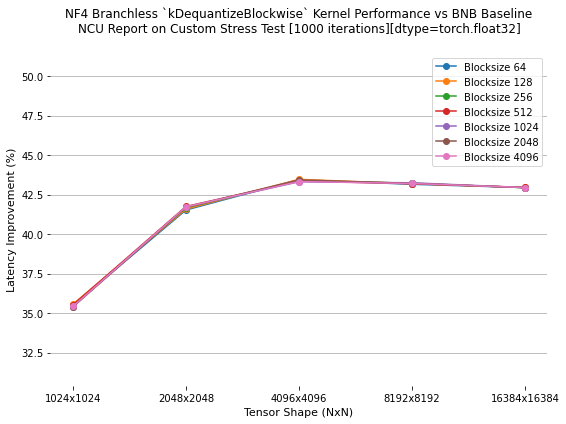

In [24]:
def plot(diff, column, kernel_name):
    d = diff.reset_index()
    d = d[d["KernelName"]==kernel_name]
    d["dim"] = d["TensorShape"]
    d["tensor_shape"] = d["dim"] ** 2

    # start plot
    fig, ax = plt.subplots(figsize=(8, 6))
    max_v, min_v = -100, 100
    for blocksize, subdf in d.groupby("Blocksize"):
        ax.plot(
            list(range(subdf[column].shape[0])),
            subdf[column].values,
            marker="o",
            label=f"Blocksize {blocksize}"
        )
        min_v = min(min_v, subdf[column].min())
        max_v = max(max_v, subdf[column].max())

    # custom ticks
    # tickvals = d["tensor_shape"].unique()
    ticktext = [f"{dim}x{dim}" for dim in d["dim"].unique()]
    # ax.set_xscale("log")
    ax.set_xticks(range(subdf[column].shape[0]))
    ax.set_xticklabels(ticktext)#, rotation=45, ha="right")
    # print(ticktext)

    # labels and title
    ax.set_xlabel("Tensor Shape (NxN)", fontsize=11)
    ax.set_ylabel("Latency Improvement (%)", fontsize=11)
    ax.set_title(
        f"NF4 Branchless `{kernel_name}` Kernel Performance vs BNB Baseline\n"
        f"NCU Report on Custom Stress Test [{N_STRESS_TEST_ITERATIONS} iterations][dtype={DTYPE}]\n"
    )
    for spine in list(ax.spines.values()):
        spine.set_visible(False)
    ax.axhline(y=0, color='black', linestyle='-', alpha=0.4)
    ax.grid(True, axis='x', alpha=0.2)
    ax.set_ylim(min_v-5, max_v+8)
    plt.tight_layout()
    plt.grid()
    plt.legend(loc="upper right")
    plt.show()

plot(ncu_diff, f"gpu__time_duration_measured_user.avg_%", "kDequantizeBlockwise")

Merge NCU report plot with Custom stress test plot and discard block sizes since the performance difference is negligible and currently there is no direct way to set the quantization blocksize from BNB quantization settings (its not exposed in transformers yet)

#### Custom Stress Test + NCU Report

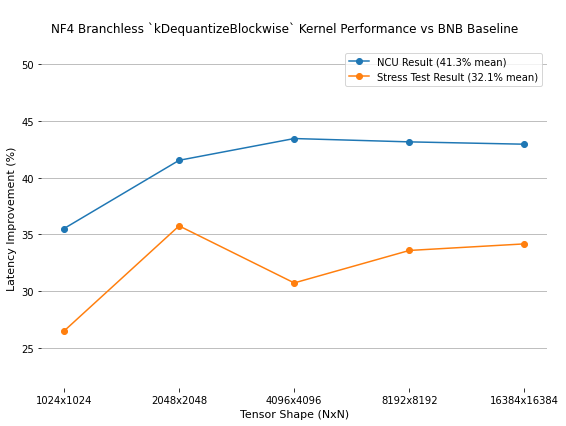

In [25]:
def plot(ncu_df, ncu_column, stress_df, stress_column, kernel_name, blocksize=64):
    df = ncu_df.reset_index()
    df = df[df["KernelName"]==kernel_name]

    # start plot
    fig, ax = plt.subplots(figsize=(8, 6))
    max_v, min_v = -100, 100
    df = df[df["Blocksize"]==blocksize]
    ncu_mean = df[ncu_column].mean()
    ax.plot(
        list(range(df[ncu_column].shape[0])),
        df[ncu_column].values,
        marker="o",
        label=f"NCU Result ({ncu_mean:.1f}% mean)"
    )
    min_v = min(min_v, df[ncu_column].min())
    max_v = max(max_v, df[ncu_column].max())
    df = stress_df.reset_index()
    df = df[df["blocksize"]==blocksize]
    stress_test_mean = df[stress_column].mean()
    ax.plot(
        list(range(df[stress_column].shape[0])),
        df[stress_column].values,
        marker="o",
        label=f"Stress Test Result ({stress_test_mean:.1f}% mean)"
    )
    min_v = min(min_v, df[stress_column].min())
    max_v = max(max_v, df[stress_column].max())
    df["dim"] = df["tensor_shape"]
    df["tensor_shape"] = df["dim"] ** 2

    # custom ticks
    # tickvals = d["tensor_shape"].unique()
    ticktext = [f"{dim}x{dim}" for dim in df["dim"].unique()]
    # ax.set_xscale("log")
    ax.set_xticks(range(df[stress_column].shape[0]))
    ax.set_xticklabels(ticktext)#, rotation=45, ha="right")
    # print(ticktext)

    # labels and title
    ax.set_xlabel("Tensor Shape (NxN)", fontsize=11)
    ax.set_ylabel("Latency Improvement (%)", fontsize=11)
    for spine in list(ax.spines.values()):
        spine.set_visible(False)
    # ax.axhline(y=0, color='black', linestyle='-', alpha=0.4)
    # ax.axhline(y=ncu_mean, color='blue', linestyle='--', alpha=.4, label=f"NCU Mean ({ncu_mean:.1f}%)")
    # ax.axhline(y=stress_test_mean, color='orange', linestyle='--', alpha=.4, label=f"Stress Test Mean ({stress_test_mean:.1f}%)")
    ax.grid(True, axis='x', alpha=0.2)
    ax.set_ylim(min_v-5, max_v+8)
    fig.suptitle(
        # f"NCU Results Vs Custom Stress Test Results\n"
        f"\nNF4 Branchless `{kernel_name}` Kernel Performance vs BNB Baseline"
    )
    plt.tight_layout()
    plt.grid()
    plt.legend(loc="upper right")
    plt.show()
    return fig

fig = plot(ncu_diff, f"gpu__time_duration_measured_user.avg_%", stress_diff, f"dequantize_latency_{MEASURE}_%", "kDequantizeBlockwise")
fig.savefig("stress_test_plot.png", dpi=300, bbox_inches='tight', facecolor='white')

Observation: 
- Stress test (torch.cuda.Event): ~30% latency reduction.
- Kernel-level speedup (NCU on stress test): ~40% latency reduction.

#### Conclusion

Benchmark results for Llama-3.1-70B on H100 80GB SXM:
- Improved decode throughput by ~33% and reduced latency by ~25% for batch sizes > 1.
- Improved prefill throughput by ~12% and reduced latency by ~10% for batch size 1.
- Reduced dequantization latency for NF4 by ~40% overall.